In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

In [5]:
df = pd.read_csv("../data/wine_quality_merged.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
def quality_category(q):
    if q <= 5:
        return "bad"
    elif q == 6:
        return "average"
    else:
        return "good"

df["quality_label"] = df["quality"].apply(quality_category)

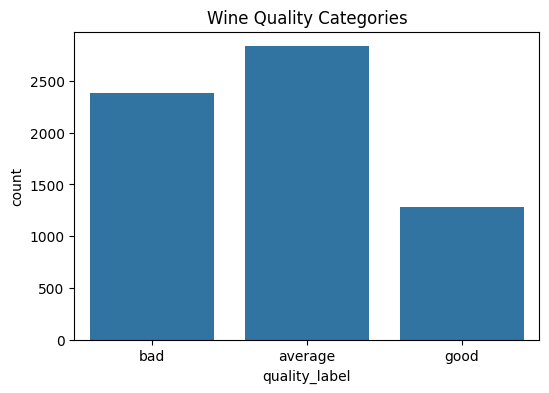

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="quality_label", data=df)
plt.title("Wine Quality Categories")
plt.savefig("../images/quality_distribution.png")
plt.show()

In [8]:
df["type"] = df["type"].map({"red":0, "white":1})

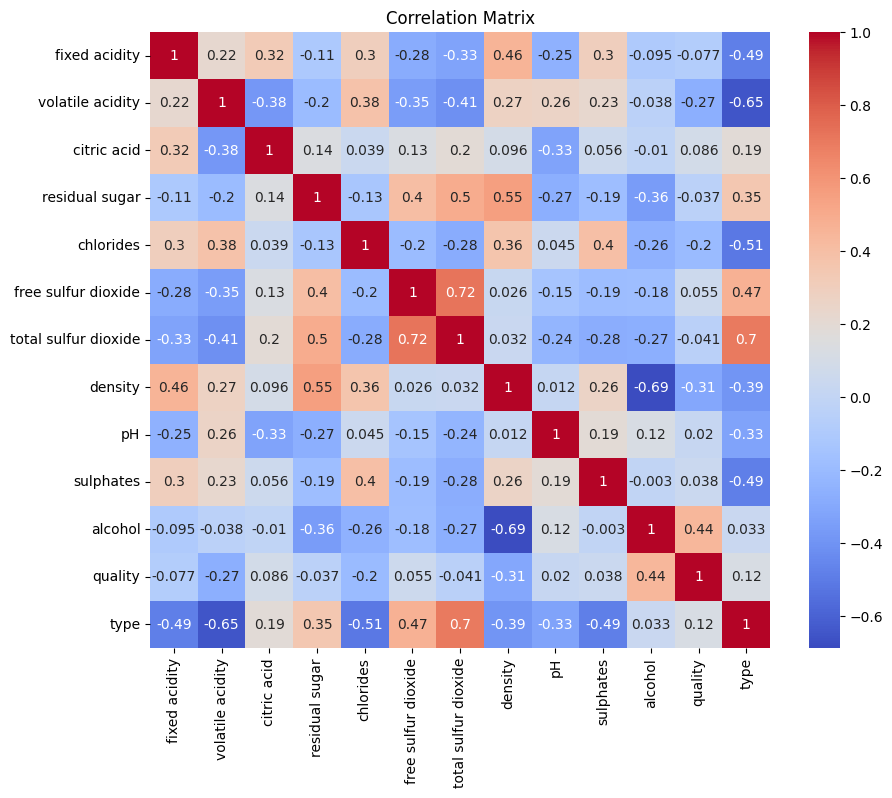

In [9]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_with_quality = numeric_df.corr()["quality"].sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=True)  
plt.title("Correlation Matrix")
plt.savefig("../images/correlation_matrix.png")
plt.show()

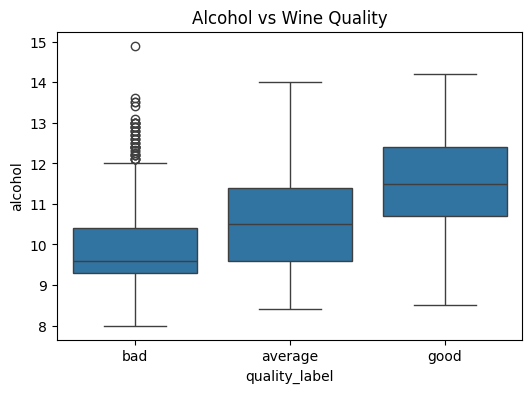

In [10]:

plt.figure(figsize=(6,4))
sns.boxplot(x="quality_label", y="alcohol", data=df)
plt.title("Alcohol vs Wine Quality")
plt.savefig("../images/alcohol_vs_quality.png")
plt.show()

In [11]:
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
accuracies = []
k_values = range(1, 31)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

best_k = k_values[accuracies.index(max(accuracies))]
print("Best k:", best_k)
print("Best accuracy:", max(accuracies))

Best k: 1
Best accuracy: 0.6553846153846153


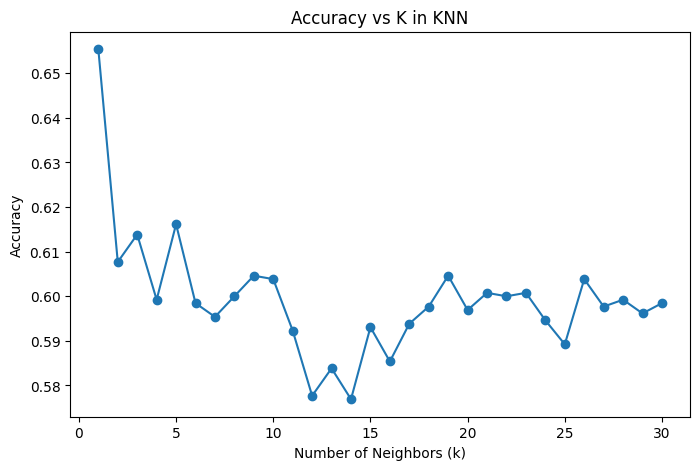

In [13]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K in KNN")
plt.savefig("../images/knn_k_selection.png")
plt.show()

In [14]:
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

In [15]:
print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Final Accuracy: 0.6553846153846153

Classification Report:

              precision    recall  f1-score   support

     average       0.63      0.65      0.64       567
         bad       0.71      0.68      0.69       477
        good       0.62      0.62      0.62       256

    accuracy                           0.66      1300
   macro avg       0.65      0.65      0.65      1300
weighted avg       0.66      0.66      0.66      1300



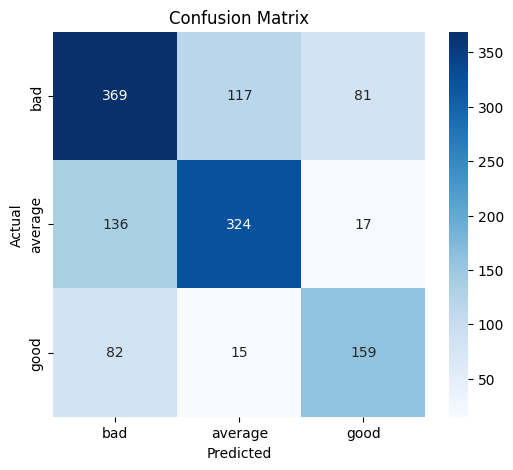

In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["bad","average","good"],
            yticklabels=["bad","average","good"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("../images/confusion_matrix.png")
plt.show()

In [17]:
joblib.dump(final_model, "../models/knn_model.pkl")

['../models/knn_model.pkl']